# Search Algorithm Demo — A* Category Traversal
**CIC6314 Artificial Intelligence | Smart Product Recommendation System**  
**Member 1 (Issye) — Search Algorithm Component**

---

## Overview

This notebook demonstrates the **A\* (A-star)** search algorithm used to find the optimal ordering
of product categories for a given customer's recommendation shortlist.

### Problem Formulation

| Element | Definition |
|---|---|
| **State space** | 8 product categories (nodes in the ALS similarity graph) |
| **Initial state** | Customer's `favourite_category` |
| **Goal** | Any eligible category reachable within `max_hops` |
| **Edge cost g(n)** | `1 − similarity(u, v)` — higher similarity → lower traversal cost |
| **Heuristic h(n)** | `1 − normalised_popularity(n)` — popular categories have lower h |
| **f(n) = g(n) + h(n)** | A\* minimises f — balancing graph proximity with category desirability |

The heuristic is **admissible**: normalised popularity ∈ [0, 1], so h ∈ [0, 1] and
never overestimates the true cost to any goal node.

### Why A\* over BFS or DFS?
- **BFS** treats all reachable categories equally — ignores edge weights and category desirability
- **DFS** does not guarantee shortest-path ordering
- **A\*** uses a popularity-based heuristic to prefer categories that are both *close to the
  customer’s favourite* (low g) **and** *globally desirable* (low h), giving the ML model
  a more informed shortlist

### Two Functions
| Function | Use case | Algorithm |
|---|---|---|
| `find_reachable_categories()` | Returning customer (has purchase history) | A\* on ALS similarity graph |
| `find_popular_categories()` | New customer (cold-start, no history) | Popularity ranking (no graph) |

## 1. Setup & Imports

In [9]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import networkx as nx
from collections import deque

from src.search_module import find_reachable_categories, find_popular_categories

# Load pkl files
with open('../models/category_similarity.pkl', 'rb') as f:
    cat_sim = pickle.load(f)

with open('../models/product_catalogue.pkl', 'rb') as f:
    catalogue = pickle.load(f)

print('✓ category_similarity.pkl loaded:', cat_sim.shape)
print('✓ product_catalogue.pkl loaded:', catalogue.shape)
print('\nCategories:', list(cat_sim.columns))

✓ category_similarity.pkl loaded: (8, 8)
✓ product_catalogue.pkl loaded: (3897, 5)

Categories: ['Home Decor', 'Kitchen & Dining', 'Seasonal & Gifts', 'Toys & Games', 'Stationery & Craft', 'Fashion & Accessories', 'Garden & Outdoor', 'Food & Confectionery']


## 2. The Category Similarity Graph

The 8×8 similarity matrix is derived from **ALS (Alternating Least Squares)** collaborative filtering — categories that are frequently purchased together by the same customers have higher similarity scores.

**Note on scale:** ALS cosine similarity values in this dataset are in the range 0.03–0.19 (not the standard 0–1), because the latent factor space is shaped by purchase sparsity. The A\* edge threshold of **0.06** is calibrated to this scale.

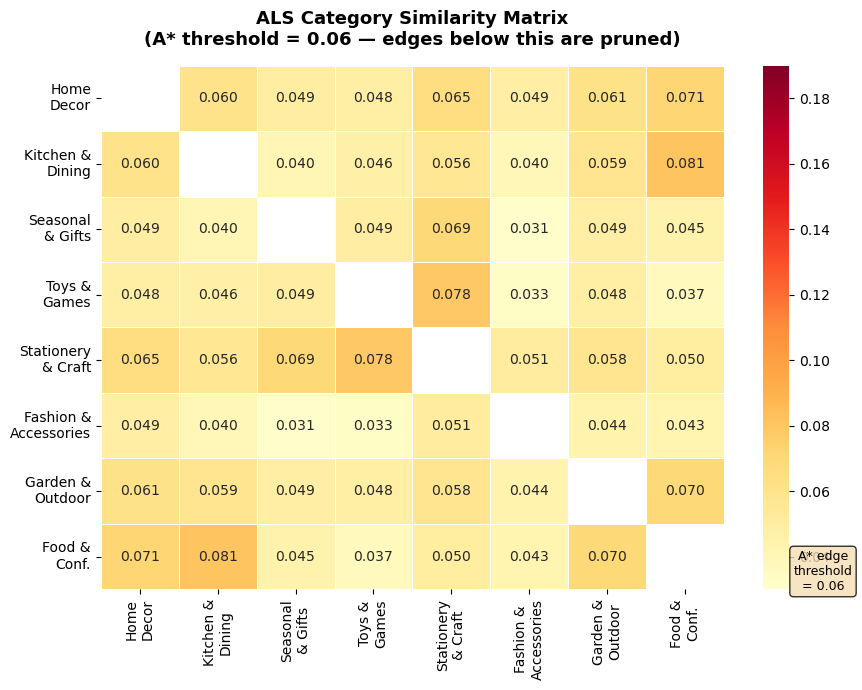


Fashion & Accessories max similarity (excluding self):
  Max = 0.0510 → below threshold 0.06 → correctly isolated by A*


In [10]:
# ── Heatmap of the full 8x8 similarity matrix ─────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 7))

# Short labels for readability
short_labels = [
    'Home\nDecor', 'Kitchen &\nDining', 'Seasonal\n& Gifts', 'Toys &\nGames',
    'Stationery\n& Craft', 'Fashion &\nAccessories', 'Garden &\nOutdoor', 'Food &\nConf.'
]

mask = np.eye(len(cat_sim), dtype=bool)  # hide diagonal (self-similarity)
sns.heatmap(
    cat_sim,
    annot=True, fmt='.3f',
    cmap='YlOrRd',
    mask=mask,
    xticklabels=short_labels,
    yticklabels=short_labels,
    linewidths=0.5,
    ax=ax,
    vmin=0.03, vmax=0.19
)

# Highlight threshold line
ax.set_title('ALS Category Similarity Matrix\n(A* threshold = 0.06 — edges below this are pruned)', 
             fontsize=13, fontweight='bold', pad=15)

# Add threshold annotation
fig.text(0.92, 0.15, 'A* edge\nthreshold\n= 0.06', ha='center', fontsize=9,
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

plt.tight_layout()
plt.show()

print("\nFashion & Accessories max similarity (excluding self):")
row = cat_sim['Fashion & Accessories'].drop('Fashion & Accessories')
print(f"  Max = {row.max():.4f} → below threshold 0.06 → correctly isolated by A*")

## 3. Category Graph Visualisation

Categories are **nodes**. An **edge** exists between two categories only if their similarity ≥ 0.06 (the A\* traversal threshold). This is the graph that A\* explores.

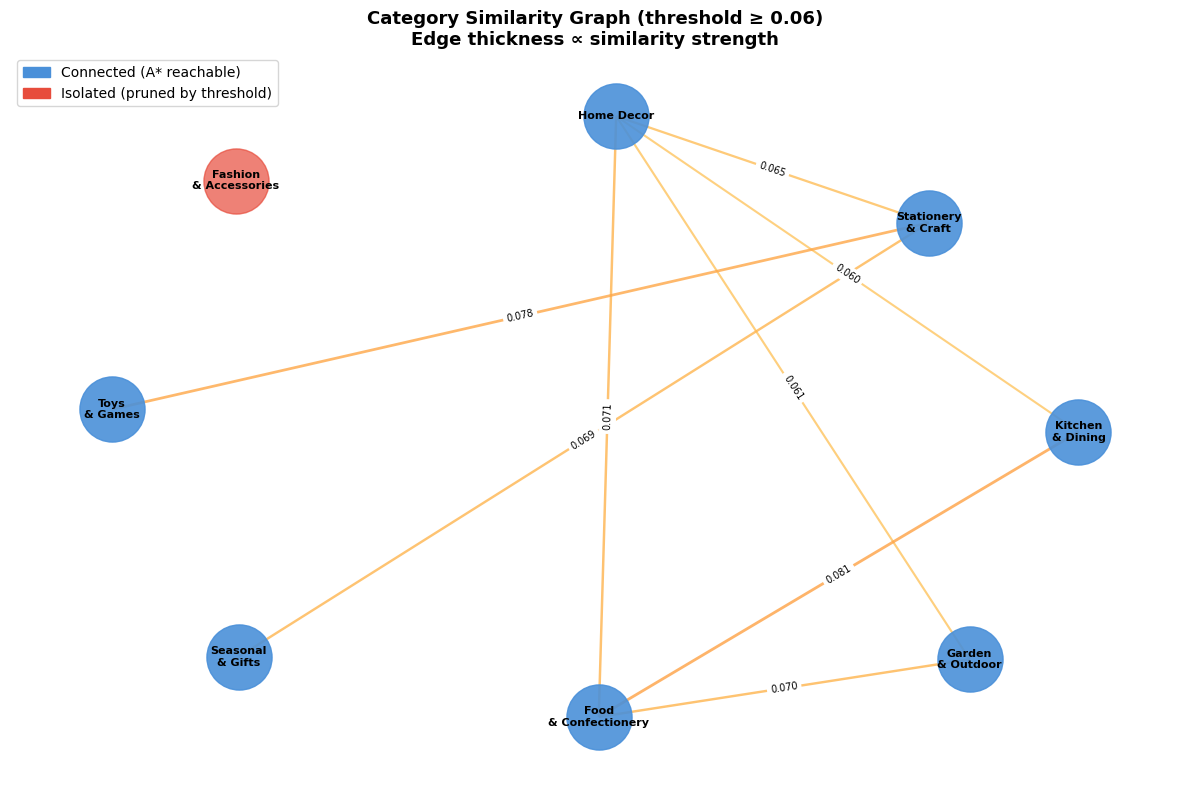

Total edges in graph: 8
Isolated nodes (max sim < 0.06): ['Fashion & Accessories']


In [11]:
THRESHOLD = 0.06

# Build NetworkX graph
G = nx.Graph()
categories = list(cat_sim.columns)
G.add_nodes_from(categories)

for i, cat_a in enumerate(categories):
    for j, cat_b in enumerate(categories):
        if i < j:
            sim = cat_sim.loc[cat_a, cat_b]
            if sim >= THRESHOLD:
                G.add_edge(cat_a, cat_b, weight=sim)

# Layout
pos = nx.spring_layout(G, seed=42, k=2.5)

fig, ax = plt.subplots(figsize=(12, 8))

edge_weights = [G[u][v]['weight'] for u, v in G.edges()]
edge_widths  = [w * 25 for w in edge_weights]
edge_colors  = [plt.cm.YlOrRd(w / 0.19) for w in edge_weights]

# Isolated nodes (Fashion & Accessories) in different colour
isolated  = [n for n in G.nodes() if G.degree(n) == 0]
connected = [n for n in G.nodes() if G.degree(n) > 0]

nx.draw_networkx_nodes(G, pos, nodelist=connected, node_size=2200,
                       node_color='#4A90D9', alpha=0.9, ax=ax)
nx.draw_networkx_nodes(G, pos, nodelist=isolated, node_size=2200,
                       node_color='#E74C3C', alpha=0.7, ax=ax)
nx.draw_networkx_edges(G, pos, width=edge_widths, edge_color=edge_colors,
                       alpha=0.8, ax=ax)

# Short labels
labels = {c: c.replace(' & ', '\n& ').replace(' (', '\n(') for c in categories}
nx.draw_networkx_labels(G, pos, labels, font_size=8, font_weight='bold', ax=ax)

# Edge weight labels
edge_labels = {(u, v): f'{G[u][v]["weight"]:.3f}' for u, v in G.edges()}
nx.draw_networkx_edge_labels(G, pos, edge_labels, font_size=7, ax=ax)

blue_patch = mpatches.Patch(color='#4A90D9', label='Connected (A* reachable)')
red_patch  = mpatches.Patch(color='#E74C3C', label='Isolated (pruned by threshold)')
ax.legend(handles=[blue_patch, red_patch], loc='upper left', fontsize=10)

ax.set_title(f'Category Similarity Graph (threshold ≥ {THRESHOLD})\nEdge thickness ∝ similarity strength',
             fontsize=13, fontweight='bold')
ax.axis('off')
plt.tight_layout()
plt.show()

print(f"Total edges in graph: {G.number_of_edges()}")
print(f"Isolated nodes (max sim < {THRESHOLD}): {isolated}")

## 4. A\* Step-by-Step Trace

To demonstrate how A\* works on this graph, we trace each step of the priority queue expansion
for a customer whose favourite category is **Home Decor**.

At each step, A\* selects the node with the lowest **f = g + h**:
- **g**: cumulative path cost from the start (sum of `1 − similarity` along edges traversed)
- **h**: heuristic — `1 − normalised_popularity` of the candidate node
- **f**: total estimated cost — A\* always expands the lowest-f node first

In [12]:
import heapq

# Precompute heuristic h(n) = 1 - normalised_popularity(n)
pop     = catalogue.groupby('category')['popularity_rank'].sum()
max_pop = float(pop.max())
h_val   = {cat: 1.0 - float(pop.get(cat, 0)) / max_pop for cat in cat_sim.columns}

print('Heuristic h(n) = 1 - normalised_popularity(n):')
for cat, h in sorted(h_val.items(), key=lambda x: x[1]):
    buyers = int(pop.get(cat, 0))
    print(f'  {cat:<28} h={h:.4f}  ({buyers:,} buyers)')


def astar_trace(start, eligible, max_hops=2, threshold=0.06):
    """A* search with step-by-step trace showing f, g, h at each expansion."""
    sep  = '=' * 70
    sep2 = '-' * 70
    print(f'\n{sep}')
    print(f" A* TRACE: start='{start}', threshold={threshold}, max_hops={max_hops}")
    print(sep)
    print(f'  Eligible : {eligible}')
    print(f'  h(start) = {h_val.get(start, 1.0):.4f}')
    print(sep2)

    open_set = [(h_val.get(start, 1.0), 0.0, 0, start)]
    settled  = {}
    results  = []
    step     = 0

    h_s = h_val.get(start, 1.0)
    print(f'  INIT | Push: (f={h_s:.4f}, g=0.00, h={h_s:.4f}, node="{start}")')

    while open_set:
        f, g, depth, node = heapq.heappop(open_set)

        if node in settled and settled[node] <= g:
            continue
        settled[node] = g
        step += 1

        h_node    = h_val.get(node, 1.0)
        elig_mark = ' <- ELIGIBLE' if node in eligible else ''
        print(f'\n  STEP {step} | Pop: "{node}"')
        print(f'         f={f:.4f}  g={g:.4f}  h={h_node:.4f}{elig_mark}')

        if node in eligible:
            results.append((f, node))
            print(f'         -> Added to results (f={f:.4f})')

        if depth >= max_hops:
            print(f'         -> max_hops={max_hops} reached, skip expanding')
            continue

        row = cat_sim[node].drop(node).sort_values(ascending=False)
        print('         Neighbours:')
        for neighbour, sim in row.items():
            if sim < threshold:
                print(f'           {neighbour:<28} sim={sim:.4f} -> BELOW threshold, stop')
                break
            if neighbour in settled:
                print(f'           {neighbour:<28} sim={sim:.4f} -> already settled')
                continue
            g_new = g + (1.0 - sim)
            h_new = h_val.get(neighbour, 1.0)
            f_new = g_new + h_new
            heapq.heappush(open_set, (f_new, g_new, depth + 1, neighbour))
            print(f'           {neighbour:<28} sim={sim:.4f}  '
                  f'edge={1-sim:.4f}  g={g_new:.4f}  h={h_new:.4f}  f={f_new:.4f} -> pushed')

    results.sort(key=lambda x: x[0])
    print(f'\n{sep}')
    print('  RESULT (ordered by f-score, lowest = most optimal):')
    for f_sc, cat in results:
        print(f'    f={f_sc:.4f}  {cat}')
    print(sep)
    return [cat for _, cat in results]


ALL_CATEGORIES = list(cat_sim.columns)
result = astar_trace('Home Decor', ALL_CATEGORIES)


Heuristic h(n) = 1 - normalised_popularity(n):
  Home Decor                   h=0.0000  (142,309 buyers)
  Kitchen & Dining             h=0.7872  (30,288 buyers)
  Seasonal & Gifts             h=0.8419  (22,497 buyers)
  Stationery & Craft           h=0.8643  (19,308 buyers)
  Garden & Outdoor             h=0.8681  (18,776 buyers)
  Fashion & Accessories        h=0.8815  (16,865 buyers)
  Toys & Games                 h=0.9312  (9,791 buyers)
  Food & Confectionery         h=0.9398  (8,564 buyers)

 A* TRACE: start='Home Decor', threshold=0.06, max_hops=2
  Eligible : ['Home Decor', 'Kitchen & Dining', 'Seasonal & Gifts', 'Toys & Games', 'Stationery & Craft', 'Fashion & Accessories', 'Garden & Outdoor', 'Food & Confectionery']
  h(start) = 0.0000
----------------------------------------------------------------------
  INIT | Push: (f=0.0000, g=0.00, h=0.0000, node="Home Decor")

  STEP 1 | Pop: "Home Decor"
         f=0.0000  g=0.0000  h=0.0000 <- ELIGIBLE
         -> Added to results (

## 5. Function 1 — `find_reachable_categories()` (Returning Customers)

Testing all 5 sample user profiles from `src/constants.py`. These use real CustomerIDs from the Online Retail dataset.

In [13]:
ALL_CATS = list(cat_sim.columns)

# Sample user profiles (from src/constants.py)
sample_profiles = [
    {
        'customer_id': 17850,
        'favourite_category': 'Home Decor',
        'customer_segment': 'High Value',
        'price_range': 'Mid-High',
        'description': 'High-value UK customer, frequent buyer'
    },
    {
        'customer_id': 14688,
        'favourite_category': 'Kitchen & Dining',
        'customer_segment': 'Regular',
        'price_range': 'Mid-Low',
        'description': 'Regular customer, kitchen focus'
    },
    {
        'customer_id': 15311,
        'favourite_category': 'Seasonal & Gifts',
        'customer_segment': 'Occasional',
        'price_range': 'Low',
        'description': 'Seasonal shopper, gift items'
    },
    {
        'customer_id': 16029,
        'favourite_category': 'Food & Confectionery',
        'customer_segment': 'Regular',
        'price_range': 'Low',
        'description': 'Regular buyer, food focus'
    },
    {
        'customer_id': None,
        'favourite_category': 'Fashion & Accessories',
        'customer_segment': 'Regular',
        'price_range': 'Mid-High',
        'description': 'Fashion buyer (isolated category test)'
    }
]

print(f"{'Customer':<12} {'Favourite Category':<25} {'Reachable Categories (A*)'  :<60} {'Count'}")
print("-" * 115)

for p in sample_profiles:
    reachable = find_reachable_categories(p, ALL_CATS, max_hops=2, threshold=0.06)
    cid = str(p['customer_id']) if p['customer_id'] else 'N/A'
    fav = p['favourite_category']
    cats_str = ', '.join(reachable)
    print(f"{cid:<12} {fav:<25} {cats_str:<60} {len(reachable)}/8")

print()
print("Note: Fashion & Accessories has max neighbour similarity of 0.059 < 0.06 threshold")
print("      → A* fallback triggers → returns full eligible list (correct behaviour)")

Customer     Favourite Category        Reachable Categories (A*)                                    Count
-------------------------------------------------------------------------------------------------------------------
17850        Home Decor                Home Decor, Kitchen & Dining, Stationery & Craft, Garden & Outdoor, Food & Confectionery, Seasonal & Gifts, Toys & Games 7/8
14688        Kitchen & Dining          Kitchen & Dining, Home Decor, Food & Confectionery, Garden & Outdoor, Stationery & Craft 5/8
15311        Seasonal & Gifts          Seasonal & Gifts, Stationery & Craft, Home Decor, Toys & Games 4/8
16029        Food & Confectionery      Home Decor, Food & Confectionery, Kitchen & Dining, Garden & Outdoor, Stationery & Craft 5/8
N/A          Fashion & Accessories     Fashion & Accessories                                        1/8

Note: Fashion & Accessories has max neighbour similarity of 0.059 < 0.06 threshold
      → A* fallback triggers → returns full eligible lis

## 6. A\* f-Score Visualisation

Each node is coloured by the A\* f-score assigned to it from **Home Decor**.
Lower f = more optimal (closer to start AND more popular).  
Node labels show `f = g + h` so the trade-off is visible.

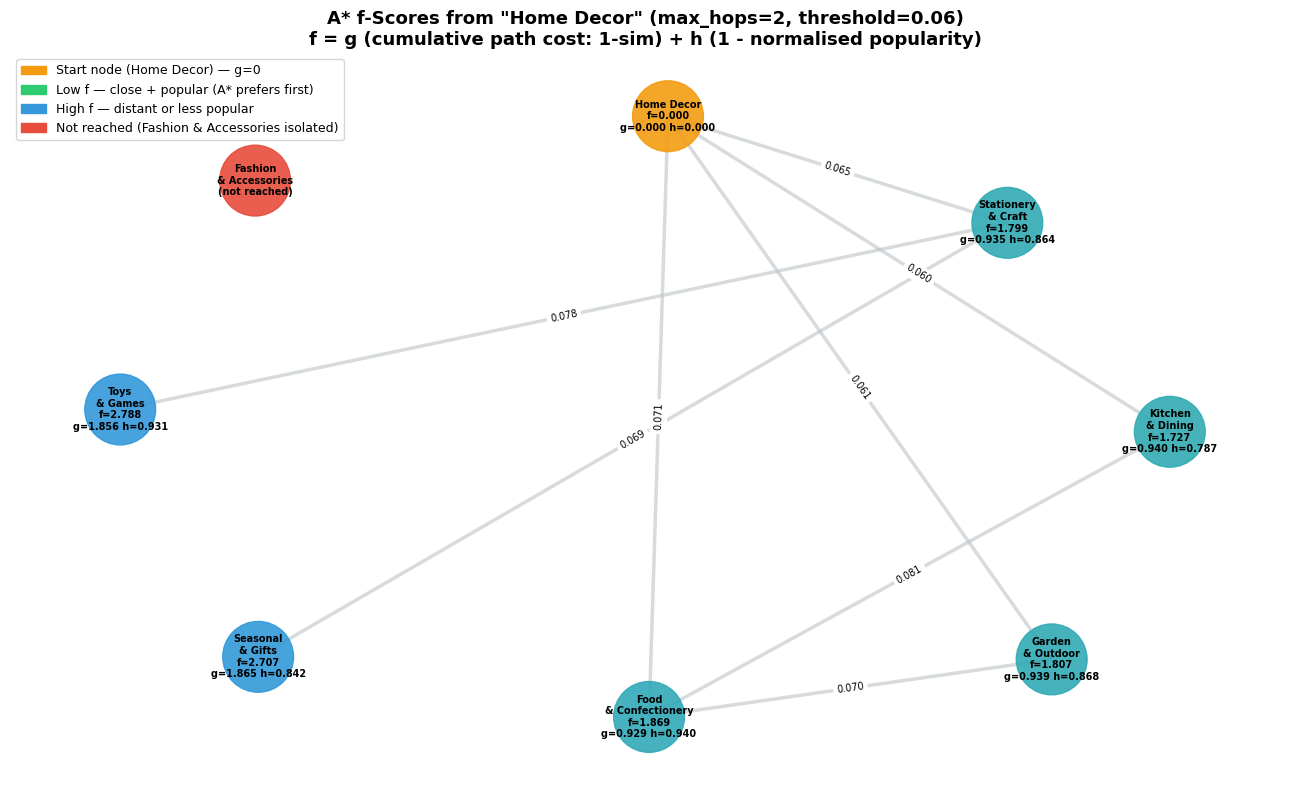

A* score table (sorted by f-score):
Category                           f       g       h  rank
----------------------------------------------------------
Home Decor                    0.0000  0.0000  0.0000  #1 <- start
Kitchen & Dining              1.7272  0.9400  0.7872  #2 
Stationery & Craft            1.7990  0.9347  0.8643  #3 
Garden & Outdoor              1.8067  0.9386  0.8681  #4 
Food & Confectionery          1.8688  0.9290  0.9398  #5 
Seasonal & Gifts              2.7072  1.8652  0.8419  #6 
Toys & Games                  2.7875  1.8563  0.9312  #7 


In [14]:
def get_astar_scores(start, max_hops=2, threshold=0.06):
    """Run A* and return {node: (f, g, h)} for every settled node."""
    open_set = [(h_val.get(start, 1.0), 0.0, 0, start)]
    settled  = {}
    scores   = {}
    while open_set:
        f, g, depth, node = heapq.heappop(open_set)
        if node in settled and settled[node] <= g:
            continue
        settled[node] = g
        scores[node]  = (round(f, 4), round(g, 4), round(h_val.get(node, 1.0), 4))
        if depth >= max_hops:
            continue
        row = cat_sim[node].drop(node).sort_values(ascending=False)
        for neighbour, sim in row.items():
            if sim < threshold:
                break
            if neighbour not in settled:
                g_new = g + (1.0 - sim)
                heapq.heappush(open_set,
                               (g_new + h_val.get(neighbour, 1.0), g_new, depth + 1, neighbour))
    return scores


START        = 'Home Decor'
astar_scores = get_astar_scores(START)

# Colour: low f (optimal) = green, high f = blue, not reached = red
f_vals    = {n: astar_scores[n][0] if n in astar_scores else None for n in G.nodes()}
reached_f = [v for v in f_vals.values() if v is not None]
f_min, f_max = min(reached_f), max(reached_f)

node_colours = []
for n in G.nodes():
    fv = f_vals[n]
    if fv is None:
        node_colours.append('#E74C3C')
    elif n == START:
        node_colours.append('#F39C12')
    else:
        t   = (fv - f_min) / (f_max - f_min + 1e-9)
        r   = int(46  + t * (52  - 46))
        g_c = int(204 + t * (152 - 204))
        b   = int(113 + t * (219 - 113))
        node_colours.append(f'#{r:02x}{g_c:02x}{b:02x}')

score_labels = {}
for n in G.nodes():
    name_short = n.replace(' & ', '\n& ')
    if n in astar_scores:
        fsc, gsc, hsc = astar_scores[n]
        score_labels[n] = f'{name_short}\nf={fsc:.3f}\ng={gsc:.3f} h={hsc:.3f}'
    else:
        score_labels[n] = f'{name_short}\n(not reached)'

fig, ax = plt.subplots(figsize=(13, 8))
nx.draw_networkx_nodes(G, pos, node_color=node_colours, node_size=2600, alpha=0.9, ax=ax)
nx.draw_networkx_edges(G, pos, width=2.5, edge_color='#BDC3C7', alpha=0.6, ax=ax)
nx.draw_networkx_labels(G, pos, score_labels, font_size=7, font_weight='bold', ax=ax)
nx.draw_networkx_edge_labels(
    G, pos, {(u, v): f'{G[u][v]["weight"]:.3f}' for u, v in G.edges()},
    font_size=7, ax=ax)

import matplotlib.patches as mpatches
ax.legend(handles=[
    mpatches.Patch(color='#F39C12', label='Start node (Home Decor) — g=0'),
    mpatches.Patch(color='#2ECC71', label='Low f — close + popular (A* prefers first)'),
    mpatches.Patch(color='#3498DB', label='High f — distant or less popular'),
    mpatches.Patch(color='#E74C3C', label='Not reached (Fashion & Accessories isolated)'),
], loc='upper left', fontsize=9)
ax.set_title(
    'A* f-Scores from "Home Decor" (max_hops=2, threshold=0.06)\n'
    'f = g (cumulative path cost: 1-sim) + h (1 - normalised popularity)',
    fontsize=13, fontweight='bold')
ax.axis('off')
plt.tight_layout()
plt.show()

print('A* score table (sorted by f-score):')
print(f'{"Category":<28} {"f":>7} {"g":>7} {"h":>7}  rank')
print('-' * 58)
for rank, (cat, (f, g_s, h)) in enumerate(
        sorted(astar_scores.items(), key=lambda x: x[1][0]), 1):
    mark = '<- start' if cat == START else ''
    print(f'{cat:<28} {f:>7.4f} {g_s:>7.4f} {h:>7.4f}  #{rank} {mark}')


## 7. Function 2 — `find_popular_categories()` (Cold-Start / New Customers)

When a customer has no purchase history, A\* cannot start (no anchor category / initial state). Instead, we rank eligible categories by total **unique buyer count** from the product catalogue.

 COLD-START — New Customer (no purchase history)

Top 3 most popular categories (by buyer count):
  #1  Home Decor                    142,309 buyers  ████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████
  #2  Kitchen & Dining              30,288 buyers  ████████████████████████████████████████████████████████████
  #3  Seasonal & Gifts              22,497 buyers  ████████████████████████████████████████████

Full category buyer count breakdown:
  Home Decor                     142,309  █████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████

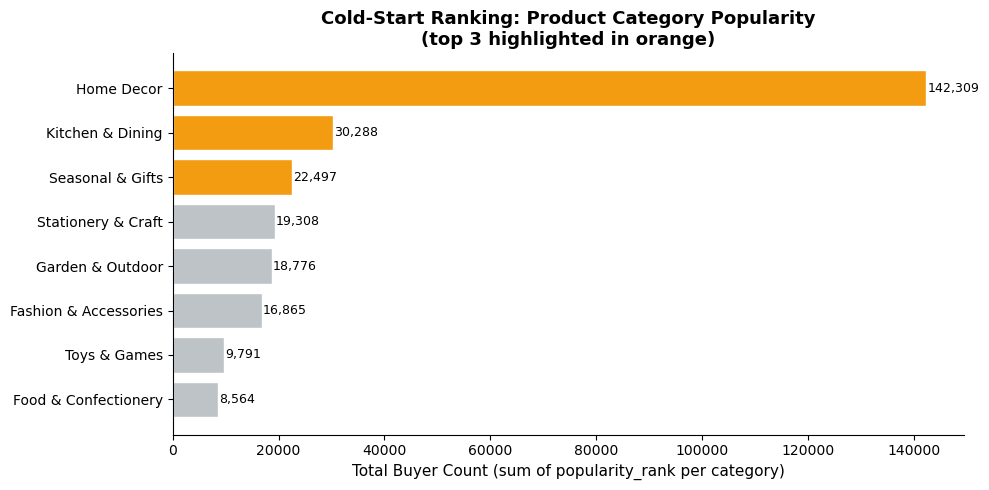

In [15]:
# Cold-start: new customer, no history
print("=" * 55)
print(" COLD-START — New Customer (no purchase history)")
print("=" * 55)

# All categories eligible (rules engine hasn't filtered anything)
top3 = find_popular_categories(ALL_CATS, price_range='Mid-Low', top_n=3)

print("\nTop 3 most popular categories (by buyer count):")
for rank, (cat, buyers) in enumerate(top3, 1):
    bar = '█' * (buyers // 500)
    print(f"  #{rank}  {cat:<28}  {buyers:>6,} buyers  {bar}")

# Buyer count per category (full breakdown)
print("\nFull category buyer count breakdown:")
counts = (
    catalogue.groupby('category')['popularity_rank']
    .sum()
    .sort_values(ascending=False)
)
for cat, cnt in counts.items():
    bar = '█' * (cnt // 500)
    print(f"  {cat:<28}  {cnt:>8,}  {bar}")

# Bar chart
fig, ax = plt.subplots(figsize=(10, 5))
colours = ['#F39C12' if i < 3 else '#BDC3C7' for i in range(len(counts))]
bars = ax.barh(counts.index[::-1], counts.values[::-1], color=colours[::-1], edgecolor='white')
ax.set_xlabel('Total Buyer Count (sum of popularity_rank per category)', fontsize=11)
ax.set_title('Cold-Start Ranking: Product Category Popularity\n(top 3 highlighted in orange)', 
             fontsize=13, fontweight='bold')

for bar, val in zip(bars, counts.values[::-1]):
    ax.text(bar.get_width() + 200, bar.get_y() + bar.get_height()/2,
            f'{val:,}', va='center', fontsize=9)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

## 8. Integration Point — How This Connects to the Full Pipeline

This search module sits between the **Rules Engine** (Member 2) and the **ML Model** (Member 3).
A* produces an f-score-ordered shortlist; the ML model then re-ranks by purchase probability.

In [16]:
print('=' * 60)
print(' SIMULATED PIPELINE')
print('=' * 60)

simulated_eligible = [
    'Home Decor', 'Kitchen & Dining', 'Seasonal & Gifts',
    'Toys & Games', 'Garden & Outdoor'
]

returning_profile = {
    'customer_id': 17850,
    'favourite_category': 'Home Decor',
    'customer_segment': 'High Value',
    'price_range': 'Mid-High'
}

print('\n[Returning Customer — A* path]')
print(f'  Input  -> eligible: {simulated_eligible}')
fav = returning_profile['favourite_category']
print(f'  Input  -> favourite_category: "{fav}"')

reachable = find_reachable_categories(returning_profile, simulated_eligible)
print(f'  Output -> A* shortlist (f-score order): {reachable}')
print(f'  -> Passes {len(reachable)} categories to ML model for final re-ranking')

print('\n[New Customer — Cold Start (popularity ranking, no A*)]')
print(f'  Input  -> eligible: {simulated_eligible}')
print('  Input  -> price_range: "Mid-High"')

popular = find_popular_categories(simulated_eligible, price_range='Mid-High', top_n=3)
print(f'  Output -> top categories: {popular}')
print('  -> Recommends top 3 by popularity directly')

print('\n' + '=' * 60)
print(' Pipeline: apply_rules -> A* search -> ML model -> output')
print('=' * 60)


 SIMULATED PIPELINE

[Returning Customer — A* path]
  Input  -> eligible: ['Home Decor', 'Kitchen & Dining', 'Seasonal & Gifts', 'Toys & Games', 'Garden & Outdoor']
  Input  -> favourite_category: "Home Decor"
  Output -> A* shortlist (f-score order): ['Home Decor', 'Kitchen & Dining', 'Garden & Outdoor', 'Seasonal & Gifts', 'Toys & Games']
  -> Passes 5 categories to ML model for final re-ranking

[New Customer — Cold Start (popularity ranking, no A*)]
  Input  -> eligible: ['Home Decor', 'Kitchen & Dining', 'Seasonal & Gifts', 'Toys & Games', 'Garden & Outdoor']
  Input  -> price_range: "Mid-High"
  Output -> top categories: [('Home Decor', 142309), ('Kitchen & Dining', 30288), ('Seasonal & Gifts', 22497)]
  -> Recommends top 3 by popularity directly

 Pipeline: apply_rules -> A* search -> ML model -> output


## 9. Summary

### A\* Problem Formulation

| Element | Value |
|---|---|
| **Algorithm** | A\* (A-star) heuristic search |
| **Graph** | 8×8 category similarity matrix derived from ALS collaborative filtering |
| **Initial state** | Customer’s `favourite_category` |
| **Goal** | Eligible categories reachable within `max_hops` |
| **Edge cost g** | `1 − similarity(u, v)` — lower similarity → higher cost |
| **Heuristic h** | `1 − normalised_popularity(n)` — admissible, h ∈ [0, 1] |
| **f(n)** | `g(n) + h(n)` — minimised by A\* |
| **Admissibility proof** | h ∈ [0, 1] and every edge cost > 0 → h never overestimates |
| **Edge threshold** | 0.06 (calibrated to ALS similarity scale 0.03–0.19) |
| **Max hops** | 2 (balances exploration vs. relevance) |
| **Cold-start path** | `find_popular_categories()` — popularity ranking, no graph traversal |
| **Fashion & Accessories** | Correctly isolated — max similarity 0.059 < 0.06 → unreachable |
| **Time complexity** | O(E log V) where V=8, E≤28 — constant for this fixed graph |

### Why A\* over BFS or DFS?

BFS treats every traversable edge equally — it finds the shortest-hop path but
ignores both edge weights (similarity strength) and node desirability.
DFS does not guarantee shortest-path ordering at all.
A\* combines path cost (g = cumulative 1−similarity) with an admissible heuristic
(h = 1−normalised popularity) to find the **minimum-cost ordering** that
simultaneously prefers categories close to the customer’s favourite **and** globally
popular — giving the downstream ML model a more informed shortlist.

The implementation is in `src/search_module.py`.